In [ ]:
import requests
import time
import pickle
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
import datetime
import json
import copy

In [ ]:
# 1695 = Open World
# 1662 = Survival
# 3810 = Sandbox
# 1100689 = Open World Survival Craft
tag_ids = [1695, 1662, 3810, 1100689]
id_set = set()
game_list = [list(), list(), list(), list()]
y = 0
tag_combinations = set()
for tag_id in tag_ids:
    request_tring = 'https://api.steampowered.com/IStoreQueryService/Query/v1/?input_json={"query":{"filters":{"type_filters":{"include_games":true},"tagids_must_match":[{"tagids":["'
    request_tring += str(tag_id)
    request_tring += '"]}]}},"context":{"language":"english","country_code":"US","steam_realm":"1"},"data_request":{"include_basic_info":""}}'
    request = requests.get(request_tring)
    data = request.json()
    response = data['response']
    count = response['metadata']['total_matching_records']
    #print(count)
    time.sleep(0.5) 
    for i in range(0,count,100):
        #print(i)
        #'{"query":{"start":"10","count":"10","filters":{"type_filters":{"include_games":true},"tagids_must_match":[{"tagids":["1100689"]}]}},"context":{"language":"english","country_code":"US"},"data_request":{"include_basic_info":""}}'
        request_tring = 'https://api.steampowered.com/IStoreQueryService/Query/v1/?input_json={"query":{"start":"'
        request_tring += str(i)
        request_tring += '","count":"100","filters":{"type_filters":{"include_games":true},"tagids_must_match":[{"tagids":["'
        request_tring += str(tag_id)
        request_tring += '"]}]}},"context":{"language":"english","country_code":"US","steam_realm":"1"},' \
        '"data_request":{"include_basic_info":false,"include_reviews":true,"include_ratings":true,"include_release":true}}'
        request = requests.get(request_tring)
        data = request.json()
        response = data['response']
        ids = response['ids']
        games = response['store_items']
        for game_id in ids:
            id_set.add(int(game_id['appid']))
        for game in games:
            game_list[y].append(game)
        time.sleep(0.5) 
        if i%100 == 0:
            print(tag_id, i, "/", count)
    y+=1

In [ ]:
pickle.dump(game_list, open("game_list", 'wb'))

In [3]:
array = pickle.load(open("game_list", 'rb')) 

In [ ]:
cursor = "*"
import urllib.parse
for i in range(182, len(testgames)):
    if "reviews" in testgames[i].keys():
        if "summary_filtered" in testgames[i]["reviews"].keys():
            if "review_count" in testgames[i]["reviews"]["summary_filtered"].keys():
             if testgames[i]["reviews"]["summary_filtered"]["review_count"] <= 1000:
                 continue
    cursor = "*"
    game_reviews = list()
    game_reviews_without_bombing = list()
    game_id = testgames[i]["id"]
    game_name = testgames[i]["name"]
    release_date = 0
    if "release" in testgames[i].keys():
        if "steam_release_date" in testgames[i]["release"].keys():
            release_date = datetime.datetime.fromtimestamp(int(testgames[i]["release"]["steam_release_date"]), datetime.UTC).strftime('%m-%d-%Y')
    for j in range(0, testgames[i]["reviews"]["summary_filtered"]["review_count"], 20):
        requeststring = f"https://store.steampowered.com/appreviews/{testgames[i]["id"]}?json=1&language=all&purchase_type=all&filter_offtopic_activity=0&filter=recent&num_per_page=20&cursor={cursor}"
        request = requests.get(requeststring)
        data = request.json()
        cursor = urllib.parse.quote_plus(data["cursor"])
        reviews_in_data = data["reviews"]
        for review in reviews_in_data:
            datum = datetime.datetime.fromtimestamp(int(review["timestamp_created"]), datetime.UTC).strftime('%m-%d-%Y')
            positive = 0
            negative = -1
            if review["voted_up"]:
                positive = 1
                negative = 0
            game_reviews.append({  "positive":positive,"negative":negative, "created":datum})
        time.sleep(0.5) 
    cursor = "*"
    for j in range(0, testgames[i]["reviews"]["summary_filtered"]["review_count"], 20):
        requeststring = f"https://store.steampowered.com/appreviews/{testgames[i]["id"]}?json=1&language=all&purchase_type=all&filter_offtopic_activity=1&filter=recent&num_per_page=20&cursor={cursor}"
        request = requests.get(requeststring)
        data = request.json()
        #print(requeststring)
        #print(data)
        cursor = urllib.parse.quote_plus(data["cursor"])
        reviews_in_data = data["reviews"]
        for review in reviews_in_data:
            datum = datetime.datetime.fromtimestamp(int(review["timestamp_created"]), datetime.UTC).strftime('%m-%d-%Y')
            positive = 0
            negative = -1
            if review["voted_up"]:
                positive = 1
                negative = 0
            game_reviews_without_bombing.append({"positive":positive,"negative":negative, "created":datum})
        time.sleep(0.5) 
    if len(game_reviews) > 100:
        print(testgames[i]["id"], len(game_reviews))
        all_games.append([game_id, game_name, release_date, pd.DataFrame(game_reviews).groupby('created', as_index=False).sum(), pd.DataFrame(game_reviews_without_bombing).groupby('created', as_index=False).sum()])
print("Done")

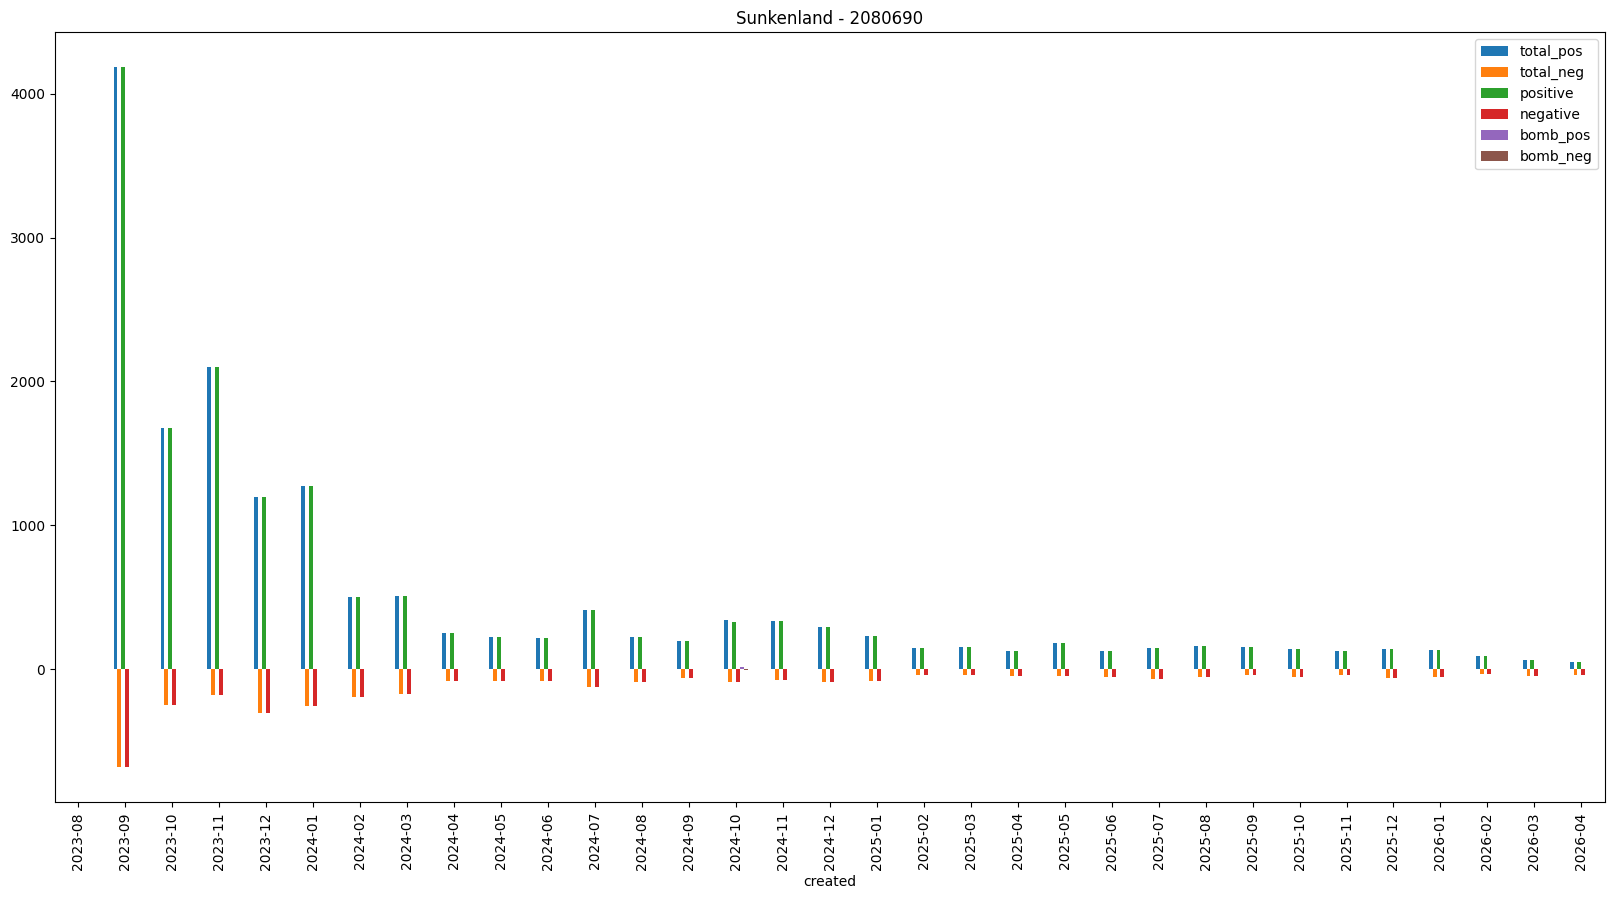

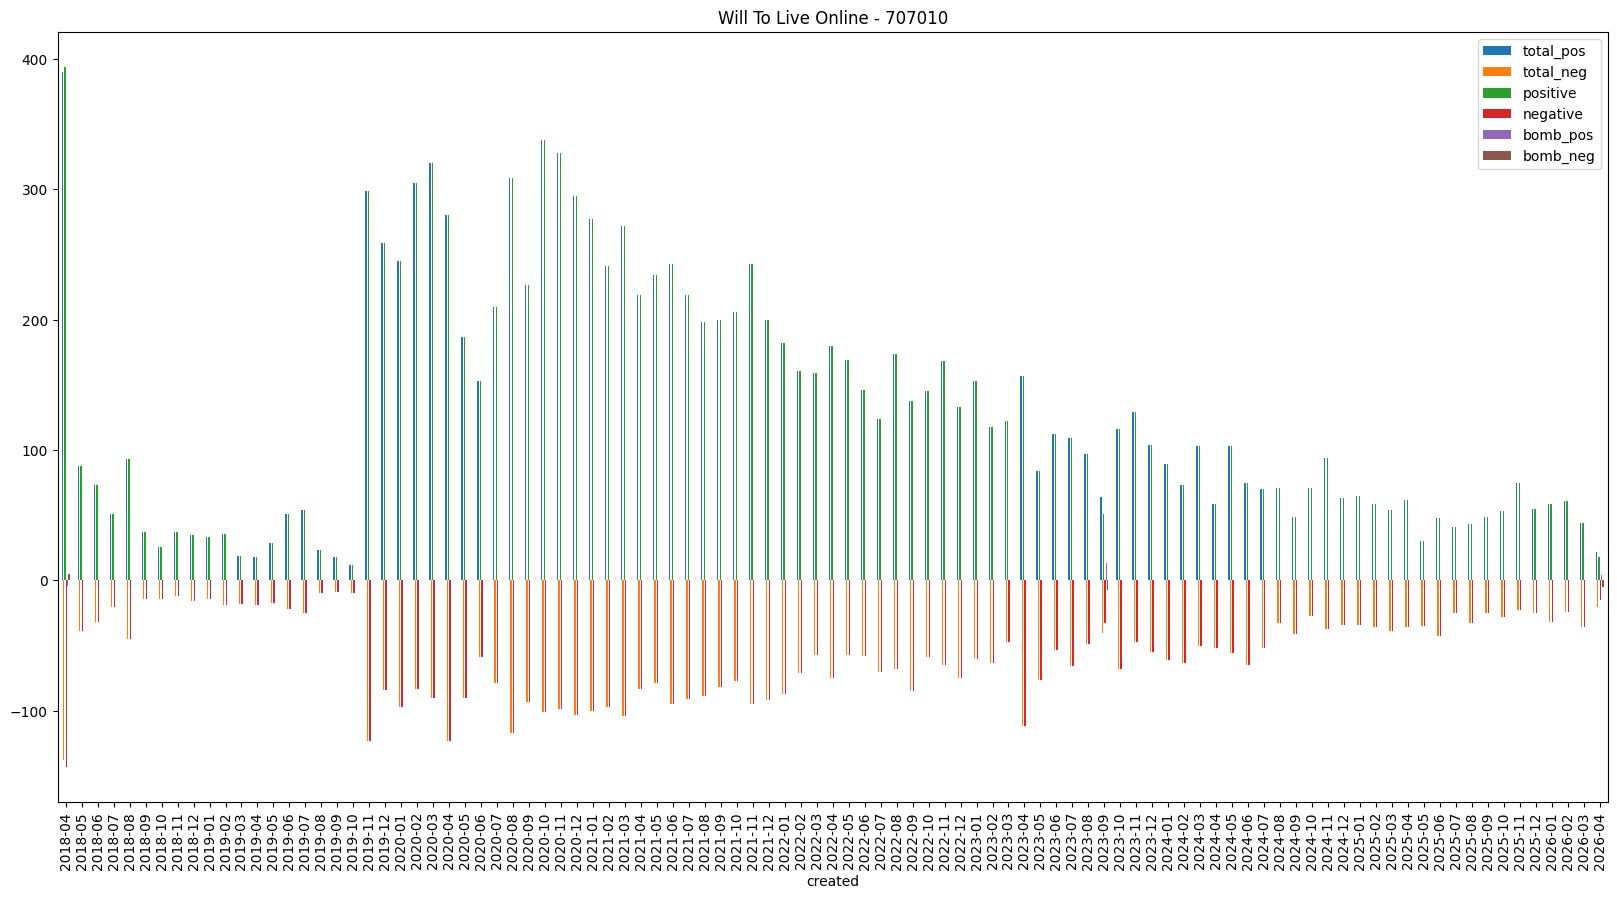

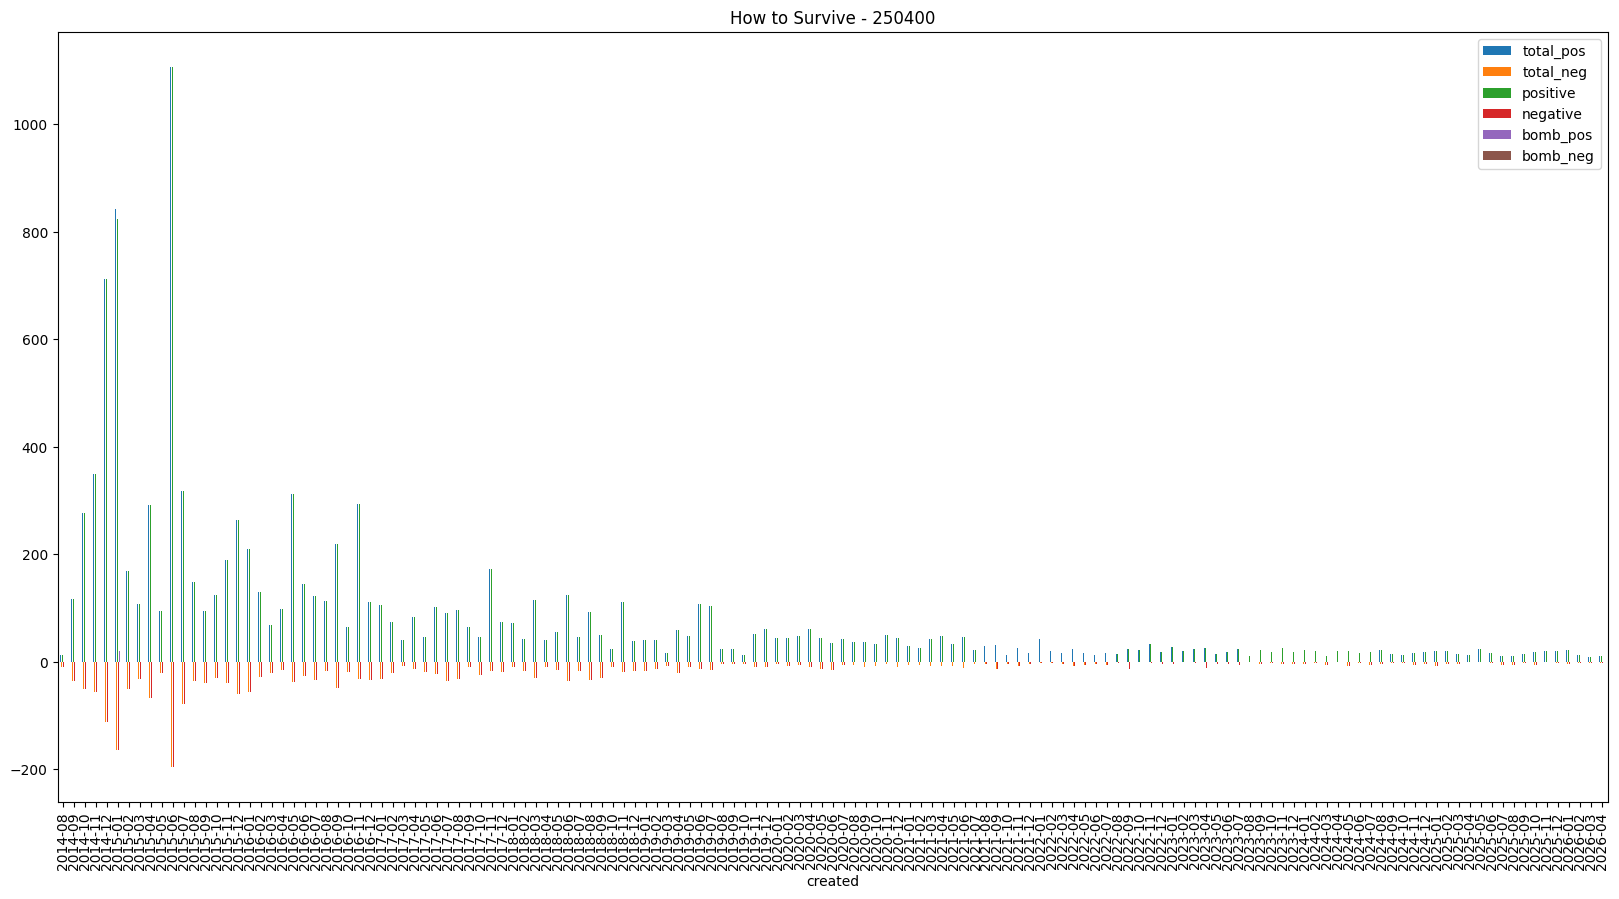

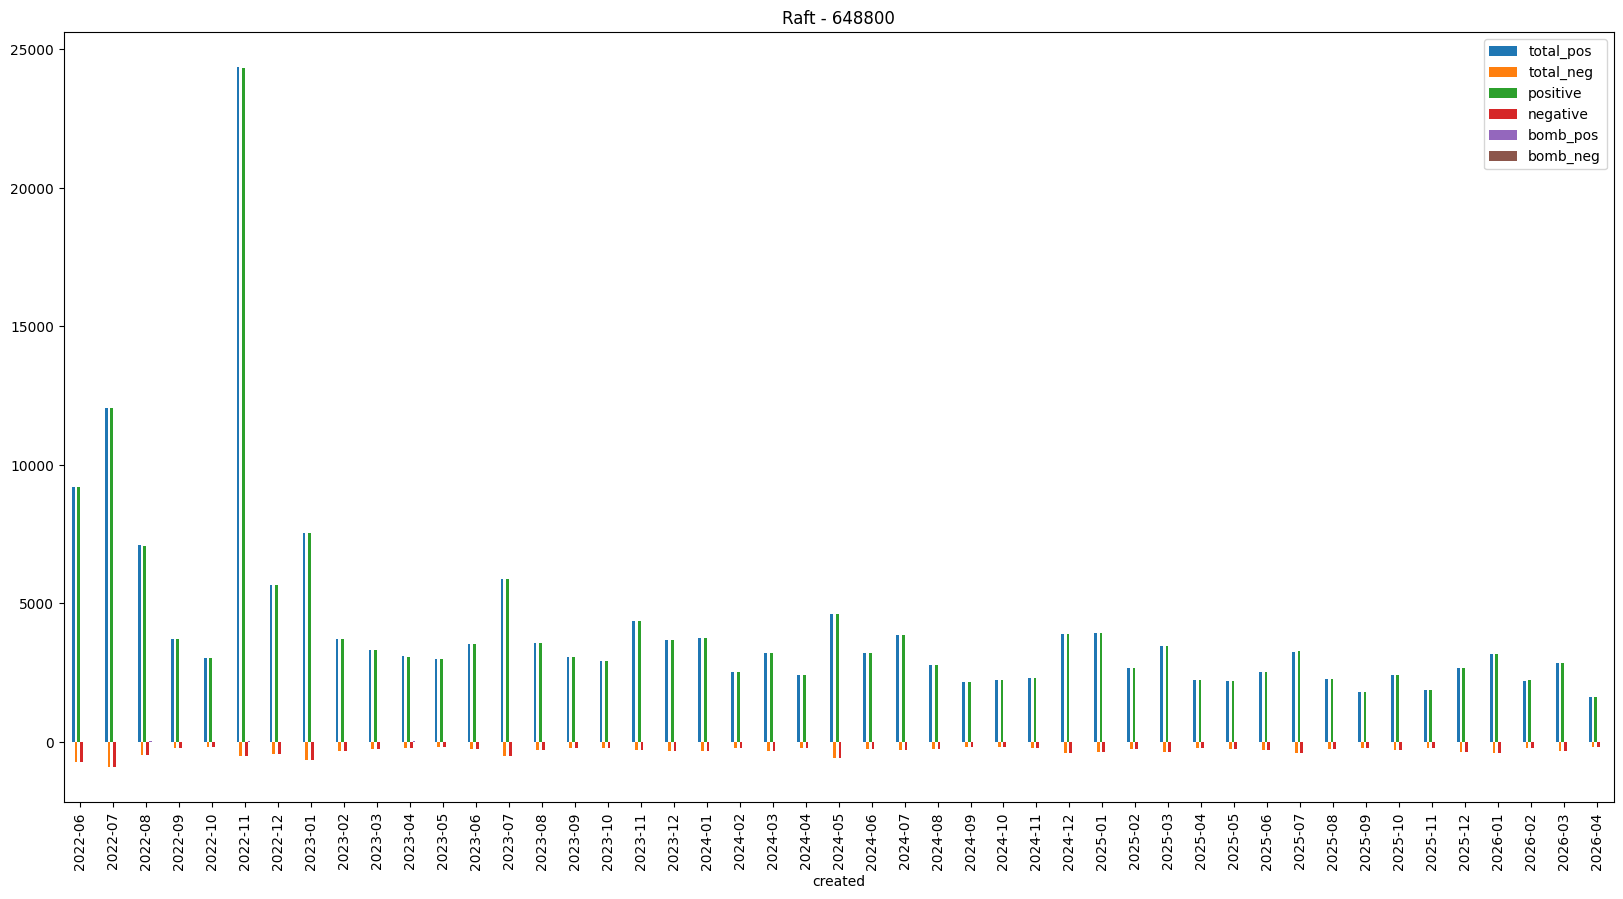

In [42]:
for i in range(len(all_games)):
    intermediate = copy.deepcopy(all_games[i][4])
    intermediate['created'] = pd.to_datetime(intermediate['created'])
    intermediate = intermediate.sort_values(by='created').reset_index(drop=True)
    earliest_date = 0
    if all_games[i][2] == 0:
        earliest_date = intermediate["created"][0]
    else:  
        earliest_date =  pd.to_datetime(all_games[i][2])
    last_date = intermediate["created"][len(intermediate["created"])-1]
    idx = pd.date_range(earliest_date, last_date)
    intermediate.index = pd.DatetimeIndex(intermediate["created"])
    intermediate = intermediate.reindex(idx, fill_value=0)
    intermediate["created"] = intermediate.index
    intermediate["created"] = intermediate["created"].map(lambda dt: dt.strftime('%Y-%m'))     

    # bombing DB
    intermediate_bombed = copy.deepcopy(all_games[i][3])
    intermediate_bombed['created'] = pd.to_datetime(intermediate_bombed['created'])
    intermediate_bombed = intermediate_bombed.sort_values(by='created').reset_index(drop=True)
    idx = pd.date_range(earliest_date, last_date)
    intermediate_bombed.index = pd.DatetimeIndex(intermediate_bombed["created"])
    intermediate_bombed = intermediate_bombed.reindex(idx, fill_value=0)
    intermediate_bombed["created"] = intermediate_bombed.index
    intermediate_bombed["created"] = intermediate_bombed["created"].map(lambda dt: dt.strftime('%Y-%m'))    

    
    
    
    combined = intermediate_bombed.groupby(['created']).sum()

    combined["bomb_pos"] = intermediate_bombed.groupby(['created']).sum()["positive"] != intermediate.groupby(['created']).sum()["positive"]
    combined["bomb_neg"] = intermediate_bombed.groupby(['created']).sum()["negative"] != intermediate.groupby(['created']).sum()["negative"]
    combined["bomb_pos"] = combined["bomb_pos"].fillna(0).astype(int) * (intermediate.groupby(['created']).sum()["positive"] - intermediate_bombed.groupby(['created']).sum()["positive"])
    combined["bomb_neg"] = combined["bomb_neg"].fillna(0).astype(int) * (intermediate.groupby(['created']).sum()["negative"] - intermediate_bombed.groupby(['created']).sum()["negative"])

    combined["total_pos"] = combined["positive"]
    combined["total_neg"] = combined["negative"]
    combined["positive"] = combined["total_pos"] - combined["bomb_pos"]
    combined["negative"] = combined["total_neg"] - combined["bomb_neg"]
    
    
    combined = combined.sort_values(by='created')
    if combined["bomb_pos"].sum(numeric_only=True) > 0 or combined["bomb_neg"].sum(numeric_only=True) > 0:
        data = {
            "id": all_games[i][0],
            "name": all_games[i][1],
            "earliest_Date": str(earliest_date),
            "last_Date": str(last_date)
        }
        with open(f"game_{all_games[i][0]}_meta.json", "w") as f:
            json.dump(data, f)
        combined.to_json(f'game_{all_games[i][0]}_reviews.json', index=True)
        combined.plot(figsize = (20,10), title = f"{all_games[i][1]} - {all_games[i][0]}", kind="bar", include_bool = True,  y=["total_pos", "total_neg", "positive", "negative", "bomb_pos", "bomb_neg"], use_index=True)